# Sequential (Recursive) Transformer Forecasting — Greek IDA2/IDA3 Prices

**Approach:** Train 1-step-ahead Transformer and iTransformer, then recursively predict 12 steps (3h).
Each prediction is fed back as the IDA_target feature for the next step.

**Models:** Vanilla Transformer Encoder + iTransformer — same architectures and Optuna search as the direct 3-horizon notebook, just horizon=1.

**Evaluation:** All 12 steps reported for comparison with direct models and other recursive models (LSTM, MLP, XGBoost).


In [1]:
!pip install optuna -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math, random, time, warnings
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.1 MB/s eta 0:00:00
Device: cuda


## 1. Data Loading (identical pipeline + IDA_target as recursive feature)


In [2]:
FILENAME = '/content/Final2026_with_ENTSOE.csv'

try:
    df = pd.read_csv(FILENAME, sep=',')
    if len(df.columns) == 1: df = pd.read_csv(FILENAME, sep=';')
except: df = pd.read_csv(FILENAME)

df = df.rename(columns={
    'Day time': 'DELIVERY_MTU', 'DAM price': 'DAM_MCP',
    'IDA1': 'MCP', 'IDA2': 'MCP_IDA2', 'IDA3': 'MCP_IDA3',
    'BM price': 'BM_IMBALANCE_PRICE', 'BMmDAM price': 'BMmDAMMCP',
})
df['DELIVERY_MTU'] = pd.to_datetime(df['DELIVERY_MTU'])
df = df.sort_values('DELIVERY_MTU').reset_index(drop=True)

df['hour'] = df['DELIVERY_MTU'].dt.hour
df['minute'] = df['DELIVERY_MTU'].dt.minute / 60.0
df['dayofweek'] = df['DELIVERY_MTU'].dt.dayofweek
df['ida3_available'] = df['MCP_IDA3'].notna().astype(float)
df['MCP_IDA3'] = df['MCP_IDA3'].fillna(0.0)
df['MCP_IDA2'] = df['MCP_IDA2'].ffill().bfill().fillna(0.0)
df['MCP'] = df['MCP'].ffill().bfill().fillna(df['MCP_IDA2'])
df['DAM_MCP'] = df['DAM_MCP'].ffill().bfill()
df['BMmDAMMCP'] = df['BMmDAMMCP'].ffill().bfill().fillna(0.0)
df['BM_IMBALANCE_PRICE'] = df['BM_IMBALANCE_PRICE'].ffill().bfill().fillna(df['BM_IMBALANCE_PRICE'].median())
df['IDA_target'] = np.where(df['ida3_available'] == 1, df['MCP_IDA3'], df['MCP_IDA2'])
df['ISP2_RES'] = df['ISP2_RES'].ffill().bfill().fillna(df['ISP1_RES'])
df['ISP2_Load'] = df['ISP2_Load'].ffill().bfill().fillna(df['ISP1_Load'])

df['DA_RES'] = df['Wind_DA_forecast'] + df['Solar_DA_forecast']
is_ida3 = df['hour'] >= 12
df['latest_RES'] = np.where(is_ida3, df['ISP3_RES'], df['ISP2_RES'])
df['latest_Load'] = np.where(is_ida3, df['ISP3_Load'], df['ISP2_Load'])
df['latest_RES_revision'] = df['latest_RES'] - df['DA_RES']
df['latest_Load_revision'] = df['latest_Load'] - df['SystemLoad_DA_forecast']
df['latest_net_load'] = df['latest_Load'] - df['latest_RES']
df['DA_net_load'] = df['SystemLoad_DA_forecast'] - df['DA_RES']
df['latest_net_load_revision'] = df['latest_net_load'] - df['DA_net_load']
df['RES_revision_ISP2_to_ISP3'] = np.where(is_ida3, df['ISP3_RES'] - df['ISP2_RES'], 0.0)
df['Load_revision_ISP2_to_ISP3'] = np.where(is_ida3, df['ISP3_Load'] - df['ISP2_Load'], 0.0)

df['bm_roll_mean_4'] = df['BM_IMBALANCE_PRICE'].rolling(4, min_periods=1).mean()
df['bm_roll_std_4'] = df['BM_IMBALANCE_PRICE'].rolling(4, min_periods=1).std().fillna(0)
df['bm_roll_mean_12'] = df['BM_IMBALANCE_PRICE'].rolling(12, min_periods=1).mean()
df['ida_momentum'] = df['MCP_IDA2'].diff(4).fillna(0)
df['mcp_momentum'] = df['MCP'].diff(4).fillna(0)
df['bm_momentum'] = df['BM_IMBALANCE_PRICE'].diff(4).fillna(0)
df['bm_ida_spread'] = df['BM_IMBALANCE_PRICE'] - df['MCP_IDA2']
df['ida_roll_std_4'] = df['MCP_IDA2'].rolling(4, min_periods=1).std().fillna(0)

# 1-step target for sequential model
df['IDA_target_1step'] = df['IDA_target'].shift(-1)

# ida3_at flags (same 3 key flags as original)
for h_steps, h_name in [(4, '1h'), (8, '2h'), (12, '3h')]:
    df[f'ida3_at_{h_name}'] = (df['hour'].shift(-h_steps) >= 12).astype(float)

df = df.dropna(subset=['IDA_target_1step']).reset_index(drop=True)
df = df[df['DELIVERY_MTU'] >= '2025-10-02'].copy().reset_index(drop=True)
df = df[df['DELIVERY_MTU'] <= '2026-01-18 23:45:00'].copy().reset_index(drop=True)

# 30 original features + IDA_target for recursive feedback
FEATURES = [
    'MCP', 'MCP_IDA2', 'DAM_MCP',
    'BM_IMBALANCE_PRICE', 'bm_roll_mean_4', 'bm_roll_std_4', 'bm_roll_mean_12', 'bm_ida_spread',
    'ida_momentum', 'mcp_momentum', 'bm_momentum', 'ida_roll_std_4',
    'SystemLoad_DA_forecast', 'Wind_DA_forecast', 'Solar_DA_forecast',
    'ida3_available', 'ida3_at_1h', 'ida3_at_2h', 'ida3_at_3h',
    'hour', 'minute', 'dayofweek',
    'latest_RES', 'latest_Load',
    'latest_RES_revision', 'latest_Load_revision', 'latest_net_load_revision', 'latest_net_load',
    'RES_revision_ISP2_to_ISP3', 'Load_revision_ISP2_to_ISP3',
    'IDA_target',  # 31st feature — recursive feedback variable
]
IDA_TARGET_IDX = len(FEATURES) - 1
TARGET = 'IDA_target_1step'
HORIZON = 1; BATCH = 64; TRAIN_RATIO = 0.8
N_FEAT = len(FEATURES)
split_idx = int(len(df) * TRAIN_RATIO)
MAX_STEPS = 12

df[FEATURES] = df[FEATURES].ffill().bfill().fillna(0)

scaler_X = MinMaxScaler()
data_X = df[FEATURES].values.astype(np.float32)
scaler_X.fit(data_X[:split_idx])
data_X_sc = scaler_X.transform(data_X)

scaler_y = MinMaxScaler()
all_tgt = df[TARGET].values.astype(np.float32).reshape(-1, 1)
scaler_y.fit(all_tgt[:split_idx])
tgt_sc = scaler_y.transform(all_tgt).flatten()

print(f"Dataset: {df.shape}, Features: {N_FEAT} (30 + IDA_target)")
print(f"Train: {split_idx}, Test: {len(df)-split_idx}")
print(f"IDA_target index: {IDA_TARGET_IDX}")



Dataset: (10464, 43), Features: 31 (30 + IDA_target)
Train: 8371, Test: 2093
IDA_target index: 30


## 2. Model Definitions

### Vanilla Transformer Encoder (horizon=1)
Timestep tokens with self-attention, identical architecture to direct notebook.

### iTransformer (horizon=1)
Feature tokens (inverted), identical architecture to direct notebook.


In [3]:
class SeqDataset(Dataset):
    def __init__(self, X, y, lb):
        self.X, self.y, self.lb = X, y, lb
    def __len__(self):
        return len(self.X) - self.lb
    def __getitem__(self, i):
        return (torch.tensor(self.X[i:i+self.lb], dtype=torch.float32),
                torch.tensor(self.y[i+self.lb], dtype=torch.float32))

# ── Positional Encoding (identical to original) ──
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# ── Vanilla Transformer Encoder (horizon=1 for sequential) ──
class TransformerForecaster(nn.Module):
    def __init__(self, n_feat, d_model, nhead, n_layers, dim_ff, horizon=1, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_feat, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu')
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model // 2, horizon))

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        x = x[:, -1, :]
        return self.fc(x).squeeze(-1)  # (batch,) for horizon=1

# ── iTransformer (horizon=1 for sequential) ──
class iTransformerForecaster(nn.Module):
    def __init__(self, n_feat, lookback, d_model, nhead, n_layers, dim_ff, horizon=1, dropout=0.1):
        super().__init__()
        self.variate_embed = nn.Linear(lookback, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu')
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc = nn.Sequential(
            nn.Linear(n_feat * d_model, d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model, horizon))

    def forward(self, x):
        x = x.permute(0, 2, 1)          # (batch, n_feat, lookback)
        x = self.variate_embed(x)        # (batch, n_feat, d_model)
        x = self.encoder(x)              # (batch, n_feat, d_model)
        x = x.flatten(1)                 # (batch, n_feat * d_model)
        return self.fc(x).squeeze(-1)    # (batch,) for horizon=1

print(f"Sequential Transformer + iTransformer defined (horizon=1, features={N_FEAT})")



Sequential Transformer + iTransformer defined (horizon=1, features=31)


## 3. Training Infrastructure


In [4]:
def train_model(model, ld_tr, ld_te, epochs, lr, label=""):
    model = model.to(device)
    crit = nn.L1Loss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_val = float('inf'); best_state = None

    for ep in range(1, epochs+1):
        model.train(); tl = 0
        for X, y in ld_tr:
            X, y = X.to(device), y.to(device)
            opt.zero_grad(); loss = crit(model(X), y); loss.backward(); opt.step()
            tl += loss.item() * X.size(0)
        tl /= len(ld_tr.dataset)

        model.eval(); vl = 0
        with torch.no_grad():
            for X, y in ld_te:
                X, y = X.to(device), y.to(device)
                vl += crit(model(X), y).item() * X.size(0)
        vl /= len(ld_te.dataset)
        sched.step()

        if vl < best_val:
            best_val = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if ep % 30 == 0 or ep == 1:
            print(f"  [{label}] {ep:3d}/{epochs} | train: {tl:.6f} | val: {vl:.6f}")

    model.load_state_dict(best_state)
    print(f"  [{label}] Best: {best_val:.6f}")
    return best_val

def compute_metrics(y_true, y_pred, y_naive):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae_naive = mean_absolute_error(y_true, y_naive)
    fsi  = 1 - mae / mae_naive
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'FSI': fsi}

print("Training infrastructure + metrics ready")



Training infrastructure + metrics ready


## 4. Optuna — Vanilla Transformer (1-step)

Same search space: lookback [24,48], d_model [32,64,128], nhead [2,4], layers 1-3, dim_ff [64,128,256].


In [5]:
SEARCH_EPOCHS = 50

def transformer_objective(trial):
    lb = trial.suggest_categorical('lookback', [24, 48])
    d_model = trial.suggest_categorical('d_model', [32, 64, 128])
    nhead = trial.suggest_categorical('nhead', [2, 4])
    n_layers = trial.suggest_int('n_layers', 1, 3)
    dim_ff = trial.suggest_categorical('dim_ff', [64, 128, 256])
    lr = trial.suggest_float('lr', 1e-4, 3e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.3, step=0.1)

    if d_model % nhead != 0:
        return float('inf')

    tr = SeqDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
    te = SeqDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
    ld_tr = DataLoader(tr, batch_size=BATCH, shuffle=True)
    ld_te = DataLoader(te, batch_size=BATCH, shuffle=False)

    torch.manual_seed(SEED)
    model = TransformerForecaster(N_FEAT, d_model, nhead, n_layers, dim_ff, HORIZON, dropout).to(device)
    crit = nn.L1Loss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val = float('inf')
    for ep in range(1, SEARCH_EPOCHS + 1):
        model.train()
        for X, y in ld_tr:
            X, y = X.to(device), y.to(device)
            opt.zero_grad(); loss = crit(model(X), y); loss.backward(); opt.step()
        model.eval(); vl = 0
        with torch.no_grad():
            for X, y in ld_te:
                X, y = X.to(device), y.to(device)
                vl += crit(model(X), y).item() * X.size(0)
        vl /= len(ld_te.dataset)
        if vl < best_val: best_val = vl
        trial.report(vl, ep)
        if trial.should_prune(): raise optuna.TrialPruned()
    return best_val

print("Running Transformer Optuna (30 trials, 1-step target)...")
tf_study = optuna.create_study(direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=15),
    sampler=optuna.samplers.TPESampler(seed=SEED))
tf_study.optimize(transformer_objective, n_trials=30, show_progress_bar=True)
bp_tf = tf_study.best_trial.params
print(f"Transformer best: {bp_tf}, val_loss={tf_study.best_trial.value:.6f}")



Running Transformer Optuna (30 trials, 1-step target)...


  0%|          | 0/30 [00:00<?, ?it/s]

Transformer best: {'lookback': 48, 'd_model': 32, 'nhead': 2, 'n_layers': 3, 'dim_ff': 128, 'lr': 0.0010001704168833305, 'dropout': 0.2}, val_loss=0.020132


## 5. Optuna — iTransformer (1-step)


In [6]:
def itransformer_objective(trial):
    lb = trial.suggest_categorical('lookback', [24, 48])
    d_model = trial.suggest_categorical('d_model', [32, 64, 128])
    nhead = trial.suggest_categorical('nhead', [2, 4])
    n_layers = trial.suggest_int('n_layers', 1, 3)
    dim_ff = trial.suggest_categorical('dim_ff', [64, 128, 256])
    lr = trial.suggest_float('lr', 1e-4, 3e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.3, step=0.1)

    if d_model % nhead != 0:
        return float('inf')

    tr = SeqDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
    te = SeqDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
    ld_tr = DataLoader(tr, batch_size=BATCH, shuffle=True)
    ld_te = DataLoader(te, batch_size=BATCH, shuffle=False)

    torch.manual_seed(SEED)
    model = iTransformerForecaster(N_FEAT, lb, d_model, nhead, n_layers, dim_ff, HORIZON, dropout).to(device)
    crit = nn.L1Loss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val = float('inf')
    for ep in range(1, SEARCH_EPOCHS + 1):
        model.train()
        for X, y in ld_tr:
            X, y = X.to(device), y.to(device)
            opt.zero_grad(); loss = crit(model(X), y); loss.backward(); opt.step()
        model.eval(); vl = 0
        with torch.no_grad():
            for X, y in ld_te:
                X, y = X.to(device), y.to(device)
                vl += crit(model(X), y).item() * X.size(0)
        vl /= len(ld_te.dataset)
        if vl < best_val: best_val = vl
        trial.report(vl, ep)
        if trial.should_prune(): raise optuna.TrialPruned()
    return best_val

print("Running iTransformer Optuna (30 trials, 1-step target)...")
it_study = optuna.create_study(direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=15),
    sampler=optuna.samplers.TPESampler(seed=SEED))
it_study.optimize(itransformer_objective, n_trials=30, show_progress_bar=True)
bp_it = it_study.best_trial.params
print(f"iTransformer best: {bp_it}, val_loss={it_study.best_trial.value:.6f}")



Running iTransformer Optuna (30 trials, 1-step target)...


  0%|          | 0/30 [00:00<?, ?it/s]

iTransformer best: {'lookback': 24, 'd_model': 32, 'nhead': 4, 'n_layers': 2, 'dim_ff': 128, 'lr': 0.0013070290350905448, 'dropout': 0.1}, val_loss=0.020654


## 6. Train Final 1-Step Models


In [7]:
EPOCHS = 120

# ── Vanilla Transformer ──
print("=" * 60)
print(f"Transformer (1-step): {bp_tf}")
lb = bp_tf['lookback']
tr = SeqDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
te = SeqDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
torch.manual_seed(SEED)
model_tf = TransformerForecaster(N_FEAT, bp_tf['d_model'], bp_tf['nhead'],
    bp_tf['n_layers'], bp_tf['dim_ff'], HORIZON, bp_tf['dropout'])
train_model(model_tf, DataLoader(tr, batch_size=BATCH, shuffle=True),
            DataLoader(te, batch_size=BATCH, shuffle=False), EPOCHS, bp_tf['lr'], "Transformer")

# ── iTransformer ──
print("=" * 60)
print(f"iTransformer (1-step): {bp_it}")
lb = bp_it['lookback']
tr = SeqDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
te = SeqDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
torch.manual_seed(SEED)
model_it = iTransformerForecaster(N_FEAT, lb, bp_it['d_model'], bp_it['nhead'],
    bp_it['n_layers'], bp_it['dim_ff'], HORIZON, bp_it['dropout'])
train_model(model_it, DataLoader(tr, batch_size=BATCH, shuffle=True),
            DataLoader(te, batch_size=BATCH, shuffle=False), EPOCHS, bp_it['lr'], "iTransformer")

print("\nBoth 1-step models trained.")



Transformer (1-step): {'lookback': 48, 'd_model': 32, 'nhead': 2, 'n_layers': 3, 'dim_ff': 128, 'lr': 0.0010001704168833305, 'dropout': 0.2}
  [Transformer]   1/120 | train: 0.066244 | val: 0.029371
  [Transformer]  30/120 | train: 0.024831 | val: 0.020846
  [Transformer]  60/120 | train: 0.022201 | val: 0.019896
  [Transformer]  90/120 | train: 0.020871 | val: 0.020546
  [Transformer] 120/120 | train: 0.020111 | val: 0.020312
  [Transformer] Best: 0.019896
iTransformer (1-step): {'lookback': 24, 'd_model': 32, 'nhead': 4, 'n_layers': 2, 'dim_ff': 128, 'lr': 0.0013070290350905448, 'dropout': 0.1}
  [iTransformer]   1/120 | train: 0.073680 | val: 0.029428
  [iTransformer]  30/120 | train: 0.022375 | val: 0.023265
  [iTransformer]  60/120 | train: 0.018979 | val: 0.021691
  [iTransformer]  90/120 | train: 0.015670 | val: 0.022968
  [iTransformer] 120/120 | train: 0.014213 | val: 0.022814
  [iTransformer] Best: 0.020923

Both 1-step models trained.


## 7. Recursive Inference — 12 Steps

Predict t+1, update IDA_target feature, shift window, repeat 12 times.
Exogenous features frozen at last known values.


In [8]:
def recursive_predict_transformer(model, data_sc, start_idx, lookback, n_steps):
    """Recursively predict n_steps using a 1-step Transformer/iTransformer."""
    model.eval()
    window = data_sc[start_idx - lookback + 1 : start_idx + 1].copy()
    predictions = []

    with torch.no_grad():
        for step in range(n_steps):
            x = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)
            pred_sc = model(x).cpu().item()
            pred_real = scaler_y.inverse_transform([[pred_sc]])[0, 0]
            predictions.append(pred_real)

            # Construct next row: copy last, update IDA_target only
            next_row = window[-1].copy()
            next_row[IDA_TARGET_IDX] = pred_sc
            window = np.vstack([window[1:], next_row.reshape(1, -1)])

    return np.array(predictions)

print("Recursive prediction function defined.")



Recursive prediction function defined.


## 8. Run Recursive Inference on Full Test Set


In [9]:
test_start = split_idx
test_end = len(df) - MAX_STEPS
n_test = test_end - test_start

print(f"Test samples: {n_test}")
print(f"Lookbacks - Transformer: {bp_tf['lookback']}, iTransformer: {bp_it['lookback']}")

all_recursive_preds = {}

# ── Transformer recursive ──
print("\nTransformer recursive inference...")
preds_tf_rec = np.zeros((n_test, MAX_STEPS))
lb = bp_tf['lookback']
model_tf.eval()
for i in range(n_test):
    idx = test_start + i
    if idx >= lb:
        preds_tf_rec[i] = recursive_predict_transformer(model_tf, data_X_sc, idx, lb, MAX_STEPS)
    if (i+1) % 500 == 0: print(f"  {i+1}/{n_test}")
all_recursive_preds['Transformer'] = preds_tf_rec
print(f"  Done. Shape: {preds_tf_rec.shape}")

# ── iTransformer recursive ──
print("\niTransformer recursive inference...")
preds_it_rec = np.zeros((n_test, MAX_STEPS))
lb = bp_it['lookback']
model_it.eval()
for i in range(n_test):
    idx = test_start + i
    if idx >= lb:
        preds_it_rec[i] = recursive_predict_transformer(model_it, data_X_sc, idx, lb, MAX_STEPS)
    if (i+1) % 500 == 0: print(f"  {i+1}/{n_test}")
all_recursive_preds['iTransformer'] = preds_it_rec
print(f"  Done. Shape: {preds_it_rec.shape}")

# ── Actuals and Naive ──
actuals_all_steps = np.zeros((n_test, MAX_STEPS))
ida_target_vals = df['IDA_target'].values.astype(np.float32)
for i in range(n_test):
    idx = test_start + i
    for s in range(MAX_STEPS):
        actuals_all_steps[i, s] = ida_target_vals[idx + s + 1]

naive_vals = ida_target_vals[test_start:test_start + n_test]

print(f"\nAll recursive predictions complete: {n_test} origins x {MAX_STEPS} steps")



Test samples: 2081
Lookbacks - Transformer: 48, iTransformer: 24

Transformer recursive inference...
  500/2081
  1000/2081
  1500/2081
  2000/2081
  Done. Shape: (2081, 12)

iTransformer recursive inference...
  500/2081
  1000/2081
  1500/2081
  2000/2081
  Done. Shape: (2081, 12)

All recursive predictions complete: 2081 origins x 12 steps


## 9. Full Results — All 12 Steps


In [10]:
# Full results at every step
print("  SEQUENTIAL (RECURSIVE) TRANSFORMER COMPARISON - ALL 12 STEPS")
print()

for name, preds in all_recursive_preds.items():
    print(f"  === {name} ===")
    print(f"  {'Step':<8} {'Horizon':>8} {'MAE':>8} {'RMSE':>8} {'R2':>7} {'FSI':>7}")
    print(f"  {'-'*55}")
    for s in range(MAX_STEPS):
        horizon_str = f"{(s+1)*15}min"
        m = compute_metrics(actuals_all_steps[:, s], preds[:, s], naive_vals)
        h_label = {4: " (1h)", 8: " (2h)", 12: " (3h)"}.get(s+1, "")
        marker = " <--" if (s+1) in [4, 8, 12] else ""
        print(f"  t+{s+1:<5} {horizon_str:>8} {m['MAE']:>8.2f} {m['RMSE']:>8.2f} {m['R2']:>7.3f} {m['FSI']*100:>+6.1f}%{h_label}{marker}")
    print()

# Naive
print(f"  === Naive (persistence) ===")
print(f"  {'Step':<8} {'Horizon':>8} {'MAE':>8} {'RMSE':>8}")
print(f"  {'-'*40}")
for s in range(MAX_STEPS):
    horizon_str = f"{(s+1)*15}min"
    mae_n = mean_absolute_error(actuals_all_steps[:, s], naive_vals)
    rmse_n = np.sqrt(mean_squared_error(actuals_all_steps[:, s], naive_vals))
    h_label = {4: " (1h)", 8: " (2h)", 12: " (3h)"}.get(s+1, "")
    marker = " <--" if (s+1) in [4, 8, 12] else ""
    print(f"  t+{s+1:<5} {horizon_str:>8} {mae_n:>8.2f} {rmse_n:>8.2f}{h_label}{marker}")

# Side-by-side MAE
print("\n\n  SIDE-BY-SIDE MAE COMPARISON (all 12 steps)")
print(f"  {'Step':<8} {'Minutes':>7}", end="")
for name in all_recursive_preds:
    print(f" {name:>14}", end="")
print(f" {'Naive':>10}")
print(f"  {'-'*65}")

for s in range(MAX_STEPS):
    horizon_str = f"{(s+1)*15}min"
    marker = " *" if (s+1) in [4, 8, 12] else ""
    print(f"  t+{s+1:<5} {horizon_str:>7}", end="")
    for name, preds in all_recursive_preds.items():
        mae = mean_absolute_error(actuals_all_steps[:, s], preds[:, s])
        print(f" {mae:>14.2f}", end="")
    mae_n = mean_absolute_error(actuals_all_steps[:, s], naive_vals)
    print(f" {mae_n:>10.2f}{marker}")
print("  (* = 1h/2h/3h horizons)")



  SEQUENTIAL (RECURSIVE) TRANSFORMER COMPARISON - ALL 12 STEPS

  === Transformer ===
  Step      Horizon      MAE     RMSE      R2     FSI
  -------------------------------------------------------
  t+1        15min    12.00    19.00   0.788  -19.6%
  t+2        30min    13.27    21.03   0.741   -3.8%
  t+3        45min    13.83    22.00   0.716  +10.1%
  t+4        60min    14.86    23.49   0.676  +14.4% (1h) <--
  t+5        75min    15.99    25.35   0.623  +19.0%
  t+6        90min    17.31    27.36   0.561  +21.1%
  t+7       105min    18.60    29.24   0.499  +21.8%
  t+8       120min    19.77    31.35   0.424  +22.8% (2h) <--
  t+9       135min    20.78    33.04   0.360  +23.7%
  t+10      150min    22.08    34.90   0.286  +23.5%
  t+11      165min    23.39    36.63   0.214  +22.9%
  t+12      180min    24.57    38.32   0.139  +22.2% (3h) <--

  === iTransformer ===
  Step      Horizon      MAE     RMSE      R2     FSI
  -------------------------------------------------------
  t

## 10. IDA2 vs IDA3 Breakdown — All 12 Steps


In [11]:
test_hours = df['hour'].values[test_start:test_start+n_test]
ida2_mask = test_hours < 12
ida3_mask = test_hours >= 12

print("  IDA2 (hours < 12) vs IDA3 (hours >= 12) - MAE at all 12 steps")
print()

for name, preds in all_recursive_preds.items():
    print(f"  === {name} ===")
    print(f"  {'Step':<8} {'Horizon':>8} {'IDA2 MAE':>10} {'IDA3 MAE':>10}")
    print(f"  {'-'*42}")
    for s in range(MAX_STEPS):
        horizon_str = f"{(s+1)*15}min"
        m2 = mean_absolute_error(actuals_all_steps[ida2_mask, s], preds[ida2_mask, s])
        m3 = mean_absolute_error(actuals_all_steps[ida3_mask, s], preds[ida3_mask, s])
        h_label = {4: " (1h)", 8: " (2h)", 12: " (3h)"}.get(s+1, "")
        print(f"  t+{s+1:<5} {horizon_str:>8} {m2:>10.2f} {m3:>10.2f}{h_label}")
    print()

# Naive
print(f"  === Naive ===")
print(f"  {'Step':<8} {'Horizon':>8} {'IDA2 MAE':>10} {'IDA3 MAE':>10}")
print(f"  {'-'*42}")
for s in range(MAX_STEPS):
    horizon_str = f"{(s+1)*15}min"
    m2 = mean_absolute_error(actuals_all_steps[ida2_mask, s], naive_vals[ida2_mask])
    m3 = mean_absolute_error(actuals_all_steps[ida3_mask, s], naive_vals[ida3_mask])
    h_label = {4: " (1h)", 8: " (2h)", 12: " (3h)"}.get(s+1, "")
    print(f"  t+{s+1:<5} {horizon_str:>8} {m2:>10.2f} {m3:>10.2f}{h_label}")



  IDA2 (hours < 12) vs IDA3 (hours >= 12) - MAE at all 12 steps

  === Transformer ===
  Step      Horizon   IDA2 MAE   IDA3 MAE
  ------------------------------------------
  t+1        15min       8.41      15.57
  t+2        30min       9.57      16.94
  t+3        45min      10.48      17.17
  t+4        60min      11.99      17.71 (1h)
  t+5        75min      13.08      18.89
  t+6        90min      14.53      20.08
  t+7       105min      15.84      21.34
  t+8       120min      17.20      22.33 (2h)
  t+9       135min      18.13      23.41
  t+10      150min      19.54      24.60
  t+11      165min      20.92      25.84
  t+12      180min      22.38      26.74 (3h)

  === iTransformer ===
  Step      Horizon   IDA2 MAE   IDA3 MAE
  ------------------------------------------
  t+1        15min       9.16      15.52
  t+2        30min      10.76      17.45
  t+3        45min      11.64      18.51
  t+4        60min      12.78      19.22 (1h)
  t+5        75min      14.22      20.8

## 11. Error Accumulation Plot


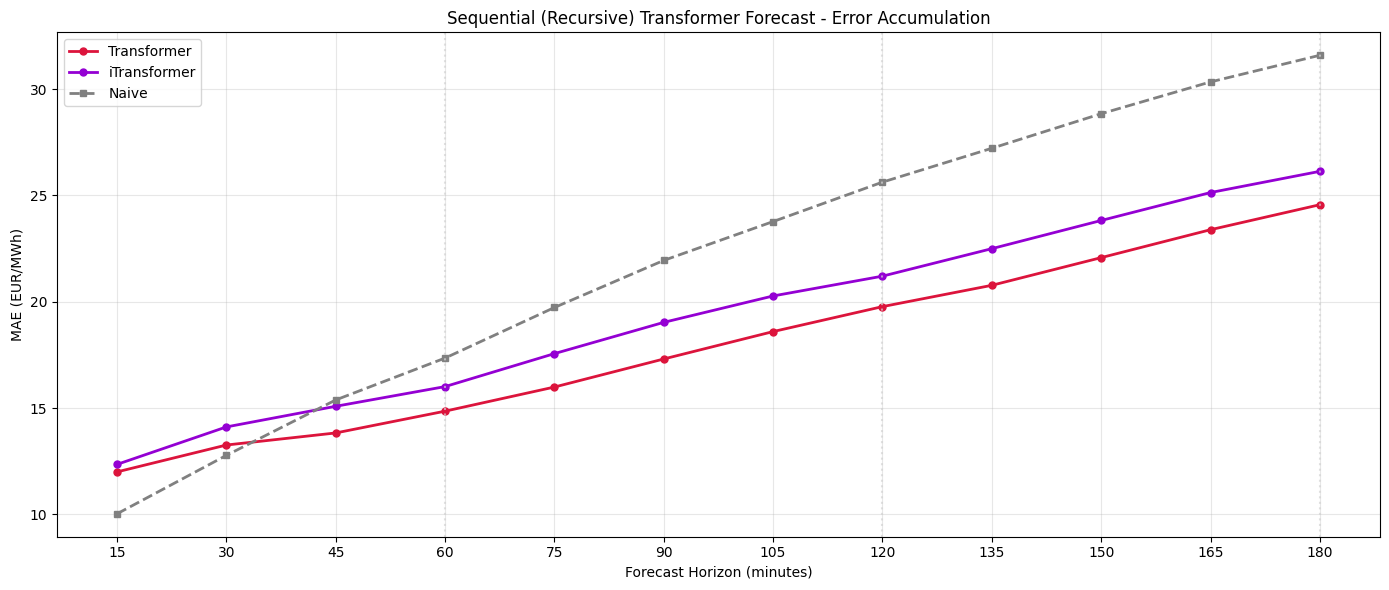

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = {'Transformer': 'crimson', 'iTransformer': 'darkviolet'}
steps = np.arange(1, MAX_STEPS + 1)
minutes = steps * 15

for name, preds in all_recursive_preds.items():
    maes = [mean_absolute_error(actuals_all_steps[:, s], preds[:, s]) for s in range(MAX_STEPS)]
    ax.plot(minutes, maes, 'o-', color=colors[name], label=name, linewidth=2, markersize=5)

naive_maes = [mean_absolute_error(actuals_all_steps[:, s], naive_vals) for s in range(MAX_STEPS)]
ax.plot(minutes, naive_maes, 's--', color='gray', label='Naive', linewidth=2, markersize=5)

for step_min in [60, 120, 180]:
    ax.axvline(step_min, color='lightgray', linestyle=':', alpha=0.7)

ax.set_xlabel('Forecast Horizon (minutes)')
ax.set_ylabel('MAE (EUR/MWh)')
ax.set_title('Sequential (Recursive) Transformer Forecast - Error Accumulation')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xticks(minutes)
plt.tight_layout(); plt.show()



## 12. Prediction Plots — All 12 Steps


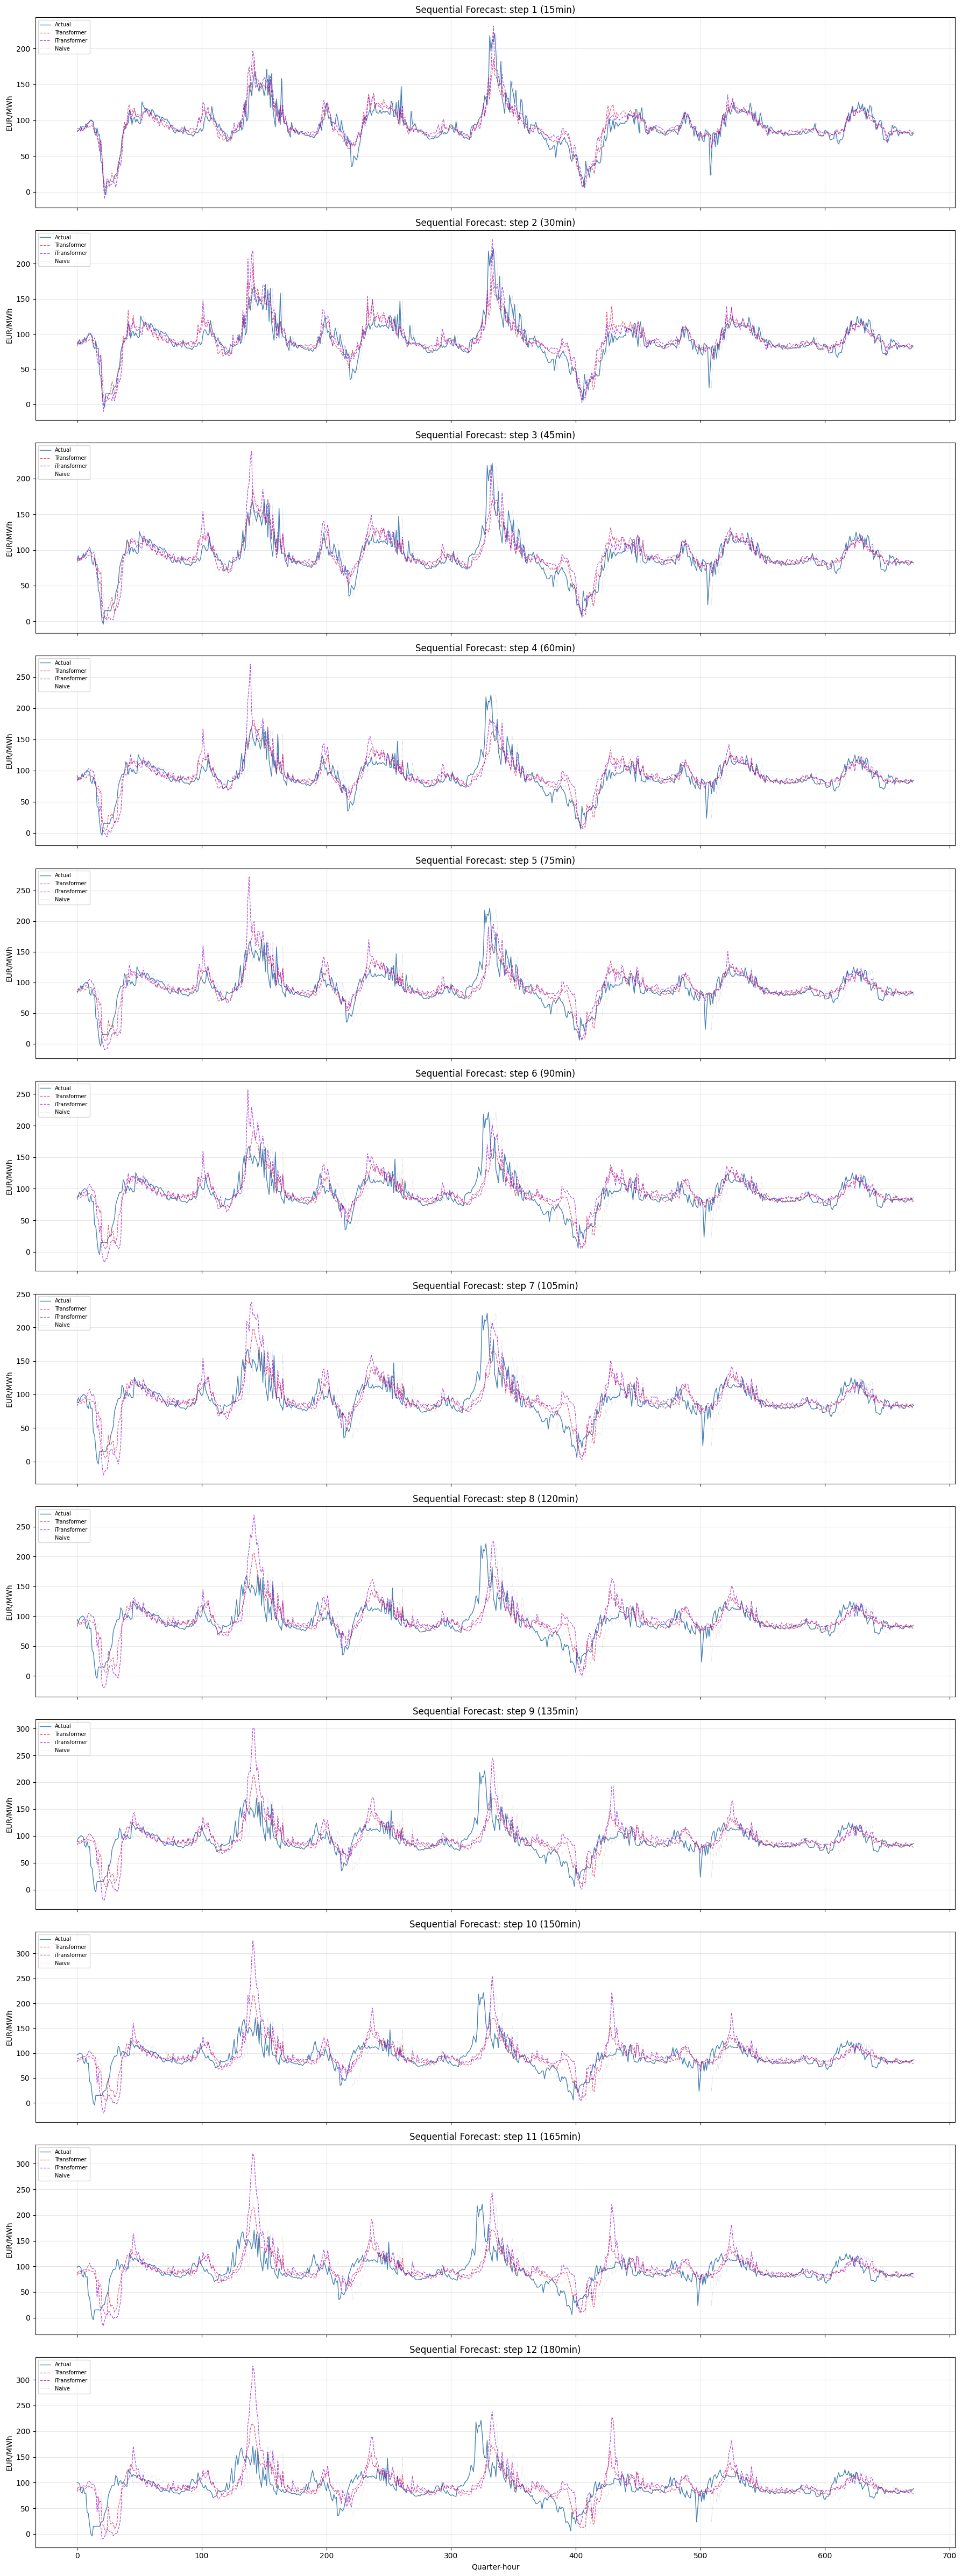

In [13]:
N_PLOT = 96 * 7
colors = {'Transformer': 'crimson', 'iTransformer': 'darkviolet'}

fig, axes = plt.subplots(12, 1, figsize=(18, 48), sharex=True)
for s, ax in enumerate(axes):
    ax.plot(actuals_all_steps[:N_PLOT, s], color='steelblue', linewidth=1, label='Actual')
    for name, preds in all_recursive_preds.items():
        ax.plot(preds[:N_PLOT, s], color=colors[name], linewidth=0.9,
                linestyle='--', alpha=0.7, label=name)
    ax.plot(naive_vals[:N_PLOT], color='gray', linewidth=0.6,
            linestyle=':', alpha=0.4, label='Naive')
    ax.set_ylabel('EUR/MWh')
    ax.set_title(f'Sequential Forecast: step {s+1} ({(s+1)*15}min)')
    ax.legend(loc='upper left', fontsize=7); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Quarter-hour')
plt.tight_layout(); plt.show()



## 13. Error Distributions — All 12 Steps


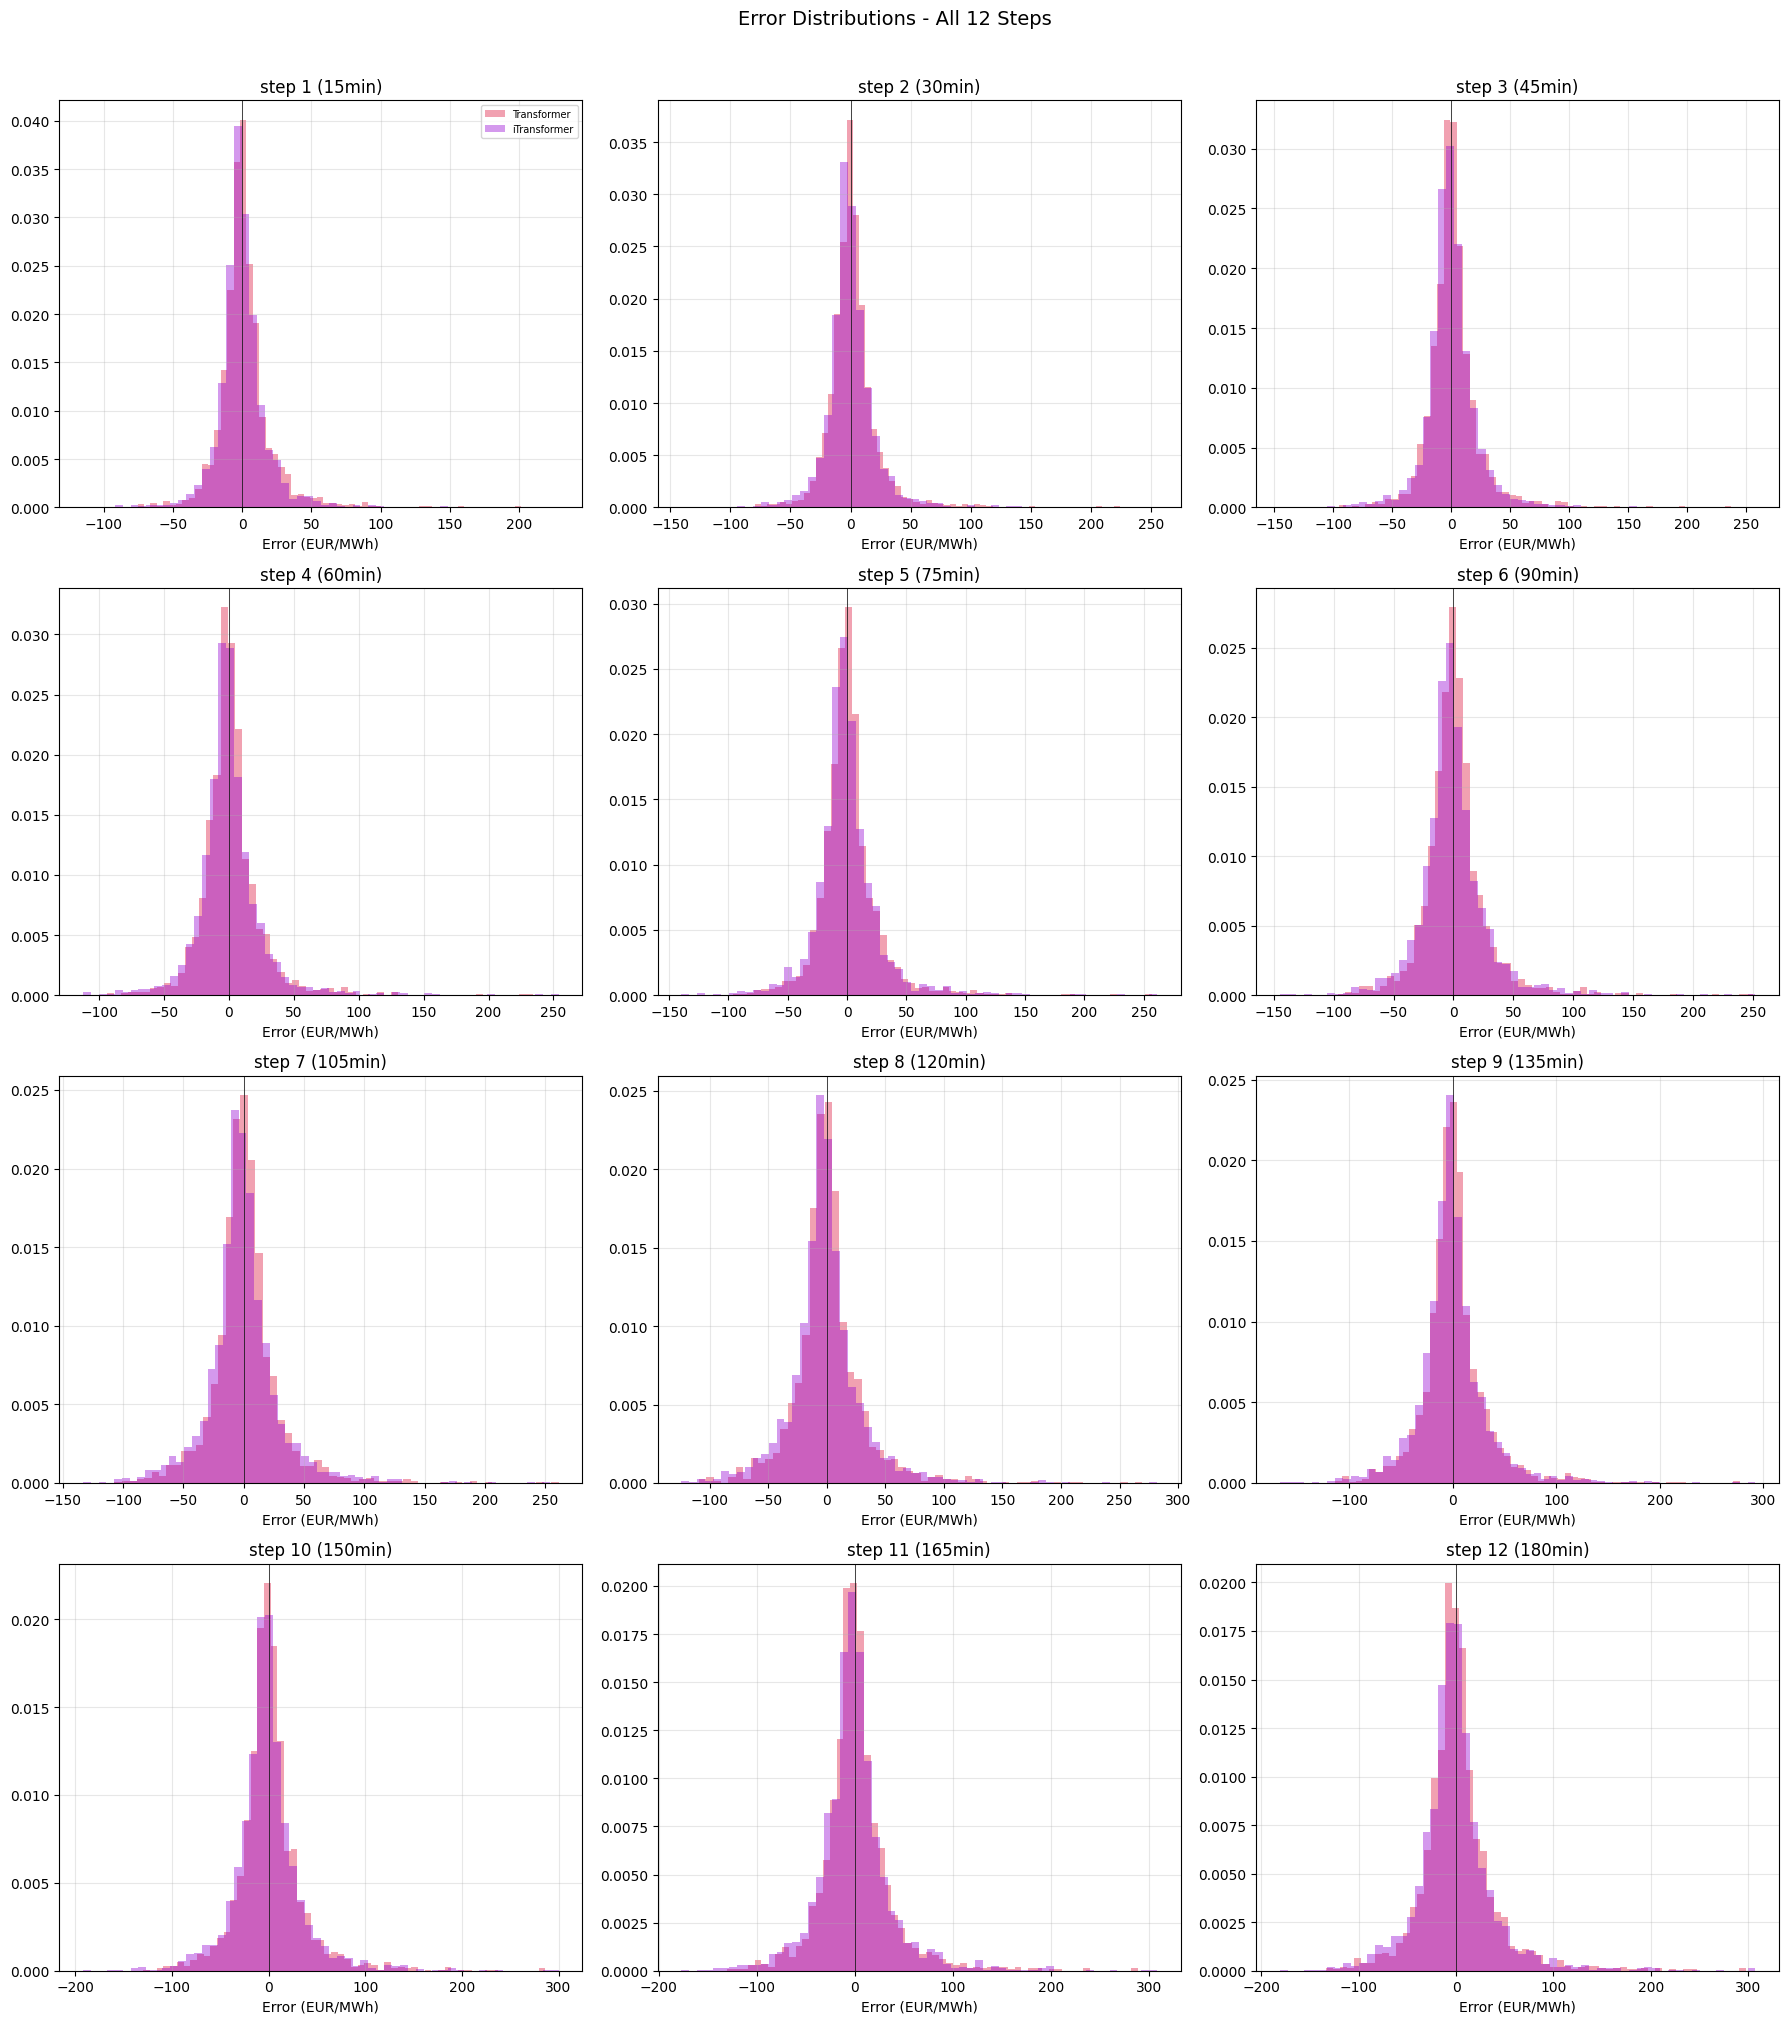

In [14]:
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
colors = {'Transformer': 'crimson', 'iTransformer': 'darkviolet'}

for s in range(MAX_STEPS):
    ax = axes[s // 3, s % 3]
    for name, preds in all_recursive_preds.items():
        err = actuals_all_steps[:, s] - preds[:, s]
        ax.hist(err, bins=60, alpha=0.4, color=colors[name], label=name, density=True)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(f'step {s+1} ({(s+1)*15}min)')
    ax.set_xlabel('Error (EUR/MWh)')
    if s == 0: ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Error Distributions - All 12 Steps', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()



## 14. Optuna History


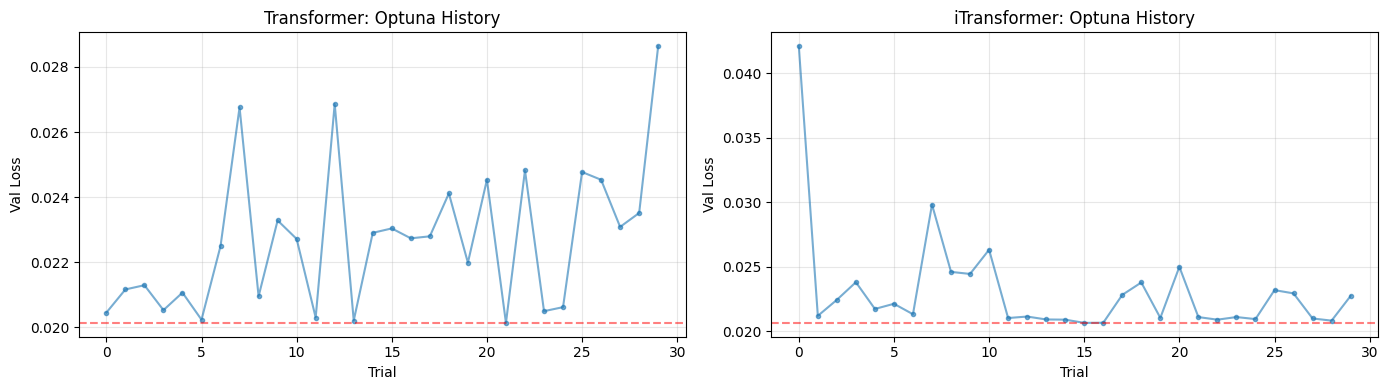

Transformer best params: {'lookback': 48, 'd_model': 32, 'nhead': 2, 'n_layers': 3, 'dim_ff': 128, 'lr': 0.0010001704168833305, 'dropout': 0.2}
iTransformer best params: {'lookback': 24, 'd_model': 32, 'nhead': 4, 'n_layers': 2, 'dim_ff': 128, 'lr': 0.0013070290350905448, 'dropout': 0.1}


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, study, name in zip(axes, [tf_study, it_study], ['Transformer', 'iTransformer']):
    vals = [t.value for t in study.trials if t.value and t.value < float('inf')]
    ax.plot(vals, 'o-', markersize=3, alpha=0.6)
    ax.axhline(min(vals), color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'{name}: Optuna History'); ax.set_xlabel('Trial'); ax.set_ylabel('Val Loss')
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Transformer best params: {bp_tf}")
print(f"iTransformer best params: {bp_it}")



## 15. Export


In [16]:
ts = df['DELIVERY_MTU'].values[test_start:test_start+n_test]
out = pd.DataFrame({'timestamp': ts})
out['hour'] = pd.to_datetime(ts).hour

for name, preds in all_recursive_preds.items():
    for s in range(MAX_STEPS):
        out[f'{name}_step{s+1}'] = preds[:, s]
for s in range(MAX_STEPS):
    out[f'actual_step{s+1}'] = actuals_all_steps[:, s]
out['naive'] = naive_vals

out.to_csv('sequential_transformer_predictions.csv', index=False)
print(f"Exported: {out.shape}")

from google.colab import files
files.download('sequential_transformer_predictions.csv')



Exported: (2081, 39)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 16. Summary

| Model | Architecture | Attention Over | Horizon | Feedback |
|---|---|---|---|---|
| **Transformer** | Encoder (timestep tokens) | Timesteps | 1-step recursive | IDA_target fed back |
| **iTransformer** | Encoder (feature tokens) | Features | 1-step recursive | IDA_target fed back |

**Protocol:** Identical to LSTM/MLP/XGBoost recursive notebook:
- 1-step target, same 31 features (30 original + IDA_target)
- Recursive inference with frozen exogenous features
- Same Optuna search spaces, AdamW + CosineAnnealing, 120 epochs
- All 12 steps evaluated for fair cross-model comparison
